In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [45]:
df = pd.read_csv('placement.csv')
df

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57
...,...,...
195,6.93,2.46
196,5.89,2.57
197,7.21,3.24
198,7.63,3.96


Checking the pattern of dataset

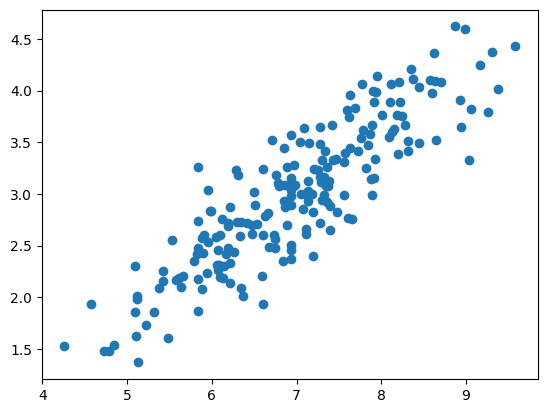

In [46]:
plt.scatter(df['cgpa'],df['package'])

Splitting of data

In [47]:
X = df['cgpa']
y = df['package']

In [48]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [49]:
#converting Series into 1D array using "values" then converting futher into 2Darray using reshape
X_train = X_train.values.reshape(-1,1)
X_test = X_test.values.reshape(-1,1)
y_train = y_train.values.reshape(-1,1)
y_test = y_test.values.reshape(-1,1)

# Linear Regression Modeling

In [50]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train,y_train)

LinearRegression()

In [51]:
y_pred = lr.predict(X_test)
y_pred

array([[2.78031348],
       [3.13635249],
       [3.1995207 ],
       [2.38981908],
       [3.52684689],
       [3.76803461],
       [3.16506531],
       [2.54486832],
       [3.17655044],
       [3.4923915 ],
       [1.90744364],
       [2.34962112],
       [3.6876387 ],
       [2.75734322],
       [3.47516381],
       [3.04447145],
       [2.32665086],
       [3.20526327],
       [2.17734418],
       [3.314372  ],
       [2.45298729],
       [2.90090734],
       [3.32011456],
       [2.87219451],
       [3.33734226],
       [2.19457187],
       [1.41932564],
       [2.7114027 ],
       [3.18229301],
       [2.32665086],
       [3.74506435],
       [2.95833298],
       [3.68189614],
       [2.97556068],
       [2.59080884],
       [3.34882738],
       [2.47595755],
       [3.07318428],
       [4.17575671],
       [2.95833298]])

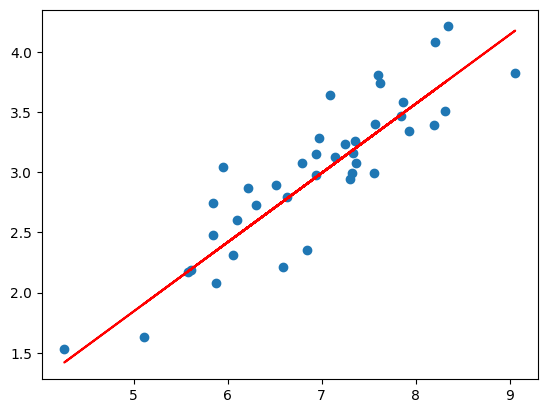

In [52]:
plt.scatter(X_test,y_test)
plt.plot(X_test,y_pred,color='red')
plt.show()

In [53]:
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)

0.7730984312051673

## SELF BUILD SLR

In [54]:
class SLR:

  def __init__(self):
    self.m = None
    self.b = None

  def fit(self,X_train,y_train):
    num = 0
    den = 0
    for i in range(X_train.shape[0]):
      num = num + (X_train[i] - X_train.mean())*(y_train[i] - y_train.mean())  # E[(Xi - Mean of X)*(yi - Mean of y)]
      den = den + (X_train[i] - X_train.mean())**2                             # E[Square of (Xi - Mean of X)]

    self.m = num / den
    self.b = y_train.mean() - (self.m * X_train.mean())                        # b = Mean of y - m*Mean of X
    print(self.m)
    print(self.b)

  def predict(self,X_test):
    return self.m * X_test + self.b                                            # y_pred = m*x + b

In [55]:
slr = SLR()

In [56]:
slr.fit(X_train,y_train)

[0.57425647]
[-1.02700694]


In [57]:
slr.predict(X_test[0])

array([2.78031348])

In [58]:
y_predself = slr.predict(X_test)
y_predself

array([[2.78031348],
       [3.13635249],
       [3.1995207 ],
       [2.38981908],
       [3.52684689],
       [3.76803461],
       [3.16506531],
       [2.54486832],
       [3.17655044],
       [3.4923915 ],
       [1.90744364],
       [2.34962112],
       [3.6876387 ],
       [2.75734322],
       [3.47516381],
       [3.04447145],
       [2.32665086],
       [3.20526327],
       [2.17734418],
       [3.314372  ],
       [2.45298729],
       [2.90090734],
       [3.32011456],
       [2.87219451],
       [3.33734226],
       [2.19457187],
       [1.41932564],
       [2.7114027 ],
       [3.18229301],
       [2.32665086],
       [3.74506435],
       [2.95833298],
       [3.68189614],
       [2.97556068],
       [2.59080884],
       [3.34882738],
       [2.47595755],
       [3.07318428],
       [4.17575671],
       [2.95833298]])

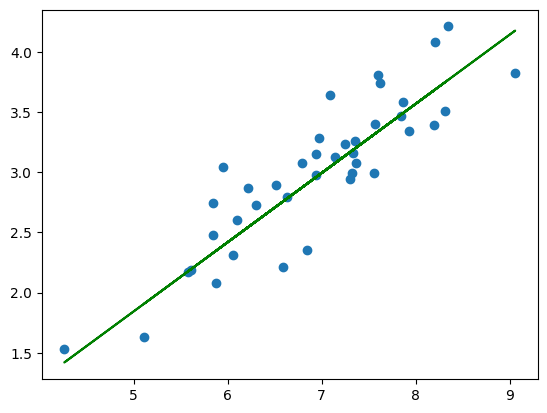

In [59]:
plt.scatter(X_test,y_test)
plt.plot(X_test,y_predself,color='green')
plt.show()